In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
import os
import psutil
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [3]:
# df0 = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_cadences_unique_nearby_star_sample_only.csv')
df0 = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_NSS_cadences_turboSETI_BLISS_062326.csv')
df0

,Unnamed: 0,Target,RA,DEC,Distance (pc),Cadence ID,Cadence Type,Receiver,Vmag,Spectral Type,...,.dat path 3,.dat path 4,.dat path 5,.dat path 6,bliss .dat path 1,bliss .dat path 2,bliss .dat path 3,bliss .dat path 4,bliss .dat path 5,bliss .dat path 6
0,0,GJ1002,0 6 42.9,-7 32 51,4.69,3635,ABACAD,Rcvr1_2,13.7,M5.0V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...
1,1,GJ1002,0 6 42.9,-7 32 51,4.69,9642,ABACAD,Rcvr2_3,13.7,M5.0V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...
2,2,GJ1002,0 6 42.9,-7 32 51,4.69,12847,ABACAD,Rcvr4_6,13.7,M5.0V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...,/datax/scratch/benjb/bl_nearby_stars/respliced...
3,3,GJ1002,0 6 42.9,-7 32 51,4.69,423617,ABACAD,Rcvr4_6,13.7,M5.0V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...
4,4,GJ1002,0 6 42.9,-7 32 51,4.69,423617,ABACAD,Rcvr4_6,13.7,M5.0V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,39172,SO0253,2 53 4.68,16 51 52,3.85,421558,ABACAD,Rcvr8_10_NEW,15.1,M6.5V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...,/datax/scratch/benjb/bl_nearby_stars/all_bliss...
39173,39173,SO0253,2 53 4.68,16 51 52,3.85,421558,ABACAD,Rcvr8_10_NEW,15.1,M6.5V,...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/set

In [4]:
bliss_dats = np.concatenate(
    (df0['bliss .dat path 1'].values,
    df0['bliss .dat path 2'].values,
    df0['bliss .dat path 3'].values,
    df0['bliss .dat path 4'].values,
    df0['bliss .dat path 5'].values,
    df0['bliss .dat path 6'].values)
)
bliss_dats = bliss_dats[bliss_dats.astype(str)!='nan']
lfvec = []
ldvec = []
lsvec = []
sfvec = []
sdvec = []
ssvec = []
cfvec = []
cdvec = []
csvec = []
xfvec = []
xdvec = []
xsvec = []
xfvec_new = []
xdvec_new = []
xsvec_new = []

In [ ]:
dats = np.concatenate(
    (df0['.dat path 1'].values,
    df0['.dat path 2'].values,
    df0['.dat path 3'].values,
    df0['.dat path 4'].values,
    df0['.dat path 5'].values,
    df0['.dat path 6'].values)
)
print(len(dats))
udats = np.unique(dats)
print(len(udats))
lfvec = []
ldvec = []
lsvec = []
sfvec = []
sdvec = []
ssvec = []
cfvec = []
cdvec = []
csvec = []
xfvec = []
xdvec = []
xsvec = []
xfvec_new = []
xdvec_new = []
xsvec_new = []

235062
231493


In [7]:
fvec = []
dvec = []
svec = []
#wvec = []

for iii, dat in enumerate(bliss_dats):
    if iii % 1000 == 0:
        print(iii, 'out of', len(bliss_dats))
    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
    f = df['freq_start'].values
    d = df['Drift_Rate'].values
    s = df['SNR'].values
    #w = df['Full_number_of_hits'].values
    fvec.append(f)
    dvec.append(d)
    svec.append(s)
    #wvec.append(w)
print('finished appending')

0 out of 226029
1000 out of 226029
2000 out of 226029
3000 out of 226029
4000 out of 226029
5000 out of 226029
6000 out of 226029
7000 out of 226029
8000 out of 226029
9000 out of 226029
10000 out of 226029
11000 out of 226029
12000 out of 226029
13000 out of 226029
14000 out of 226029
15000 out of 226029
16000 out of 226029
17000 out of 226029
18000 out of 226029
19000 out of 226029
20000 out of 226029
21000 out of 226029
22000 out of 226029
23000 out of 226029
24000 out of 226029
25000 out of 226029
26000 out of 226029
27000 out of 226029
28000 out of 226029
29000 out of 226029
30000 out of 226029
31000 out of 226029
32000 out of 226029
33000 out of 226029
34000 out of 226029
35000 out of 226029
36000 out of 226029
37000 out of 226029
38000 out of 226029
39000 out of 226029
40000 out of 226029
41000 out of 226029
42000 out of 226029
43000 out of 226029
44000 out of 226029
45000 out of 226029
46000 out of 226029
47000 out of 226029
48000 out of 226029
49000 out of 226029
50000 out of 

In [8]:
fvec = np.concatenate(fvec)

In [ ]:
dvec = np.concatenate(dvec)
svec = np.concatenate(svec)
#wvec = np.concatenate(wvec)
#print(len(wvec))

# PICK UP HERE 092425

In [5]:
plt.scatter(fvec, svec)
plt.yscale('log')
plt.show()

KeyboardInterrupt: 

In [ ]:
for iii, dat in enumerate(udats):
    #print(dat)

    if iii % 1000 == 0:
        print(iii, 'out of', len(udats))

    if dat == 'None':
        continue

    if psutil.virtual_memory()[1] < 32e9:
        print('Tried to read too much into memory!')
        break

    argwhere = np.where(
        (df0['.dat path 1'].values == dat) | (df0['.dat path 2'].values == dat) | (df0['.dat path 3'].values == dat) |
        (df0['.dat path 4'].values == dat) | (df0['.dat path 5'].values == dat) | (df0['.dat path 6'].values == dat)
        )[0]
    receiver = df0['Receiver'].values[argwhere][0]
    cadence = df0['Cadence ID'].values[argwhere][0]

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
    if receiver == 'Rcvr1_2':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 1100) & (df['Uncorrected_Frequency'].values < 1200) |
                    (df['Uncorrected_Frequency'].values > 1340) & (df['Uncorrected_Frequency'].values < 1900))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        lfvec.append(f)
        ldvec.append(d)
        lsvec.append(s)
    elif receiver == 'Rcvr2_3':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 1800) & (df['Uncorrected_Frequency'].values < 2300) |
                    (df['Uncorrected_Frequency'].values > 2360) & (df['Uncorrected_Frequency'].values < 2700))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        sfvec.append(f)
        sdvec.append(d)
        ssvec.append(s)
    elif receiver == 'Rcvr4_6':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 4000) & (df['Uncorrected_Frequency'].values < 7800))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        cfvec.append(f)
        cdvec.append(d)
        csvec.append(s)
    elif receiver == 'Rcvr8_10':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 7800) & (df['Uncorrected_Frequency'].values < 11200))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        xfvec.append(f)
        xdvec.append(d)
        xsvec.append(s)
    elif receiver == 'Rcvr8_10_NEW':
        tdf = df.iloc[
            np.where((df['Uncorrected_Frequency'].values > 7550) & (df['Uncorrected_Frequency'].values < 11700))[0]
            ]
        f = tdf['freq_start'].values
        d = tdf['Drift_Rate'].values
        s = tdf['SNR'].values
        xfvec_new.append(f)
        xdvec_new.append(d)
        xsvec_new.append(s)
    #fb = bl.Waterfall(h5_path, load_data=False)
    #ghz = fb.header['nchans']*2.7939677238464355e-06/1e3
    #semester_counts.append([semester, receiver, len(f), ghz])

lfvec = np.concatenate(lfvec)
ldvec = np.concatenate(ldvec)
lsvec = np.concatenate(lsvec)
sfvec = np.concatenate(sfvec)
sdvec = np.concatenate(sdvec)
ssvec = np.concatenate(ssvec)
cfvec = np.concatenate(cfvec)
cdvec = np.concatenate(cdvec)
csvec = np.concatenate(csvec)
xfvec = np.concatenate(xfvec)
xdvec = np.concatenate(xdvec)
xsvec = np.concatenate(xsvec)
xfvec_new = np.concatenate(xfvec_new)
xdvec_new = np.concatenate(xdvec_new)
xsvec_new = np.concatenate(xsvec_new)

print(len(lfvec))
print(len(sfvec))
print(len(cfvec))
print(len(xfvec))
print(len(xfvec_new))

0 out of 231493
1000 out of 231493
2000 out of 231493
3000 out of 231493
4000 out of 231493
5000 out of 231493
6000 out of 231493
7000 out of 231493
8000 out of 231493
9000 out of 231493
10000 out of 231493
11000 out of 231493
12000 out of 231493
13000 out of 231493
14000 out of 231493
15000 out of 231493
16000 out of 231493
17000 out of 231493
18000 out of 231493
19000 out of 231493
20000 out of 231493
21000 out of 231493
22000 out of 231493
23000 out of 231493
24000 out of 231493
25000 out of 231493
26000 out of 231493
27000 out of 231493
28000 out of 231493
29000 out of 231493
30000 out of 231493
31000 out of 231493
32000 out of 231493
33000 out of 231493
34000 out of 231493
35000 out of 231493
36000 out of 231493
37000 out of 231493
38000 out of 231493
39000 out of 231493
40000 out of 231493
41000 out of 231493
42000 out of 231493
43000 out of 231493
44000 out of 231493
45000 out of 231493
46000 out of 231493
47000 out of 231493
48000 out of 231493
49000 out of 231493
50000 out of 

In [5]:
dfa = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/all_events.csv')
dfa

,Unnamed: 0,Cadence Index,Source,Frequency,Drift Rate,SNR
0,0,0.0,GJ1002,1599.453400,-0.756713,21.043835
1,1,10007.0,HIP20219,1557.382747,-0.010204,23.126204
2,2,10011.0,HIP20261,2107.503989,-0.081634,27.665854
3,3,10011.0,HIP20261,2107.323474,-0.081634,45.568272
4,4,10011.0,HIP20261,2107.158001,-0.081634,42.477215
...,...,...,...,...,...,...
77380,77380,9927.0,HIP19990,4089.615585,-0.010204,15.930622
77381,77381,9931.0,HIP2,1620.175648,-3.642919,11.344711
77382,77382,9940.0,HIP2,2196.310680,0.010204,14.883245
77383,77383,9940.0,HIP2,2195.775255,0.010204,102.725464


In [10]:
print(len(fvec))

826124050


0 done
1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done


AttributeError: module 'matplotlib.pyplot' has no attribute 'stairs'

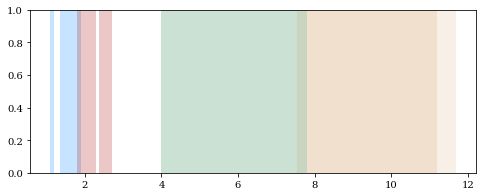

In [14]:
#fvec = np.concatenate((lfvec, sfvec, cfvec, xfvec, xfvec_new))
#event_fvec = dfa['Frequency'].values

fig = plt.subplots(1, 1, figsize=(8,3))

plt.axvspan(1.1, 1.9, color='dodgerblue', alpha=0.25, lw=0, label=r'$L$')
plt.axvspan(1.8, 2.7, color='firebrick', alpha=0.25, lw=0, label=r'$S$')
plt.axvspan(4.0, 7.8, color='seagreen', alpha=0.25, lw=0, label=r'$C$')
plt.axvspan(7.8, 11.2, color='peru', alpha=0.25, lw=0, label=r'$X$ (old)')
plt.axvspan(7.55, 7.8, color='peru', alpha=0.125, lw=0, label=r'$X$ (new)')
plt.axvspan(11.2, 11.7, color='peru', alpha=0.125, lw=0)
plt.axvspan(1.2, 1.34, color='white', lw=0, alpha=1)
plt.axvspan(2.3, 2.36, color='white', lw=0, alpha=1)

h0, bb = np.histogram(fvec[:100000000]/1000, bins=500, range=(1.1, 11.7))
print('0 done')
h1, bb = np.histogram(fvec[100000000:200000000]/1000, bins=500, range=(1.1, 11.7))
print('1 done')
h2, bb = np.histogram(fvec[200000000:300000000]/1000, bins=500, range=(1.1, 11.7))
print('2 done')
h3, bb = np.histogram(fvec[300000000:400000000]/1000, bins=500, range=(1.1, 11.7))
print('3 done')
h4, bb = np.histogram(fvec[400000000:500000000]/1000, bins=500, range=(1.1, 11.7))
print('4 done')
h5, bb = np.histogram(fvec[500000000:600000000]/1000, bins=500, range=(1.1, 11.7))
print('5 done')
h6, bb = np.histogram(fvec[600000000:700000000]/1000, bins=500, range=(1.1, 11.7))
print('6 done')
h7, bb = np.histogram(fvec[700000000:800000000]/1000, bins=500, range=(1.1, 11.7))
print('7 done')
h8, bb = np.histogram(fvec[800000000:]/1000, bins=500, range=(1.1, 11.7))
print('8 done')

#plt.hist(fvec[:100000000]/1000, bins=500, range=(1.1, 11.7), color='gray', label='hits')
#plt.hist(event_fvec/1000, bins=500, range=(1.1, 11.7), color='steelblue', label='events')
plt.stairs(h0+h1+h2+h3+h4+h5+h6+h7+h8, bb, fill=True)

plt.xlabel('frequency [GHz]')
plt.ylabel('N')
plt.yscale('log')
plt.xlim(1.1,11.7)
plt.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/full_hit_event_frequency_histogram_BLISS_example_2_062326.pdf', bbox_inches='tight')

plt.show()

In [17]:
del fvec

In [16]:
print(h0+h1+h2+h3+h4+h5+h6+h7+h8)
print(bb)

[ 2942603  7798514  4919846 33658361 17394402 11519186  7074305  3668679
  4011023  8692149 13546634  2930422  4135534  7992096  2839052  2865525
  4919974  2765158  2985228  2555725 17889244 14868301 17905601 19753805
 15263923  4604466  6036788  9028504  6168212  6019675  5233457  5334169
  5554686  6338898  6133608  5471332  9336955   734249 13669444  3314090
   436948   363845   955633   964920   451580   289779   399877  1797184
   434950   246178  1112361  4478213  1089578  1724262   417840   177794
    45338  1197096  4349813  3443141    87420   355347   505626   564253
   730222  2266401   446597   457416   405296   191778   263503   338065
   139523   140840    62368   752452   258989   142007   125231    87225
    97469    76848    61966    49054    33886    29430    73206    49776
    47779    71054    70031    41001    47311    48283    43707    51509
   498275       64       60     5291        2        0      242        1
        2        0     3989     1488       69      

In [19]:
dvec = np.concatenate(dvec)

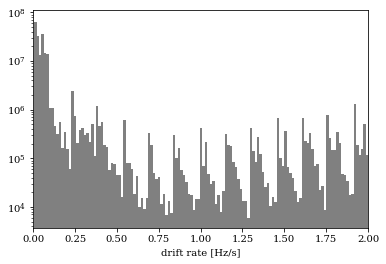

In [23]:
plt.hist(dvec, bins=500, color='gray')
plt.xlabel('drift rate [Hz/s]')
plt.yscale('log')
plt.xlim(0,2)
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/Fig_BLISS_drift_rates_zoom_062326.pdf')
plt.show()

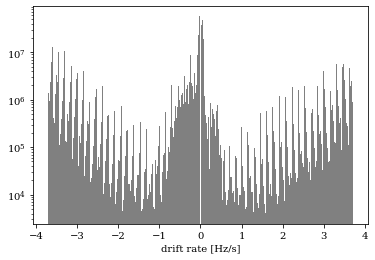

In [10]:
plt.hist(dvec, bins=500, color='gray')
plt.xlabel('drift rate [Hz/s]')
plt.yscale('log')
plt.show()

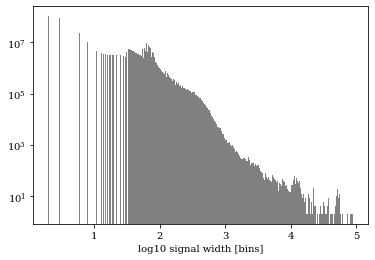

In [ ]:
plt.hist(np.log10(wvec.astype(float)), bins=500, color='gray')
plt.xlabel('log10 signal width [bins]')
plt.yscale('log')
# spot check the 10**4 signals
plt.show()

In [16]:
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_lfvec.pdf', lfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_ldvec.pdf', ldvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_lsvec.pdf', lsvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_sfvec.pdf', sfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_sdvec.pdf', sdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_ssvec.pdf', ssvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_cfvec.pdf', cfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_cdvec.pdf', cdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_csvec.pdf', csvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xfvec.pdf', xfvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xdvec.pdf', xdvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xsvec.pdf', xsvec)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xfvec_new.pdf', xfvec_new)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xdvec_new.pdf', xdvec_new)
np.save('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_xsvec_new.pdf', xsvec_new)

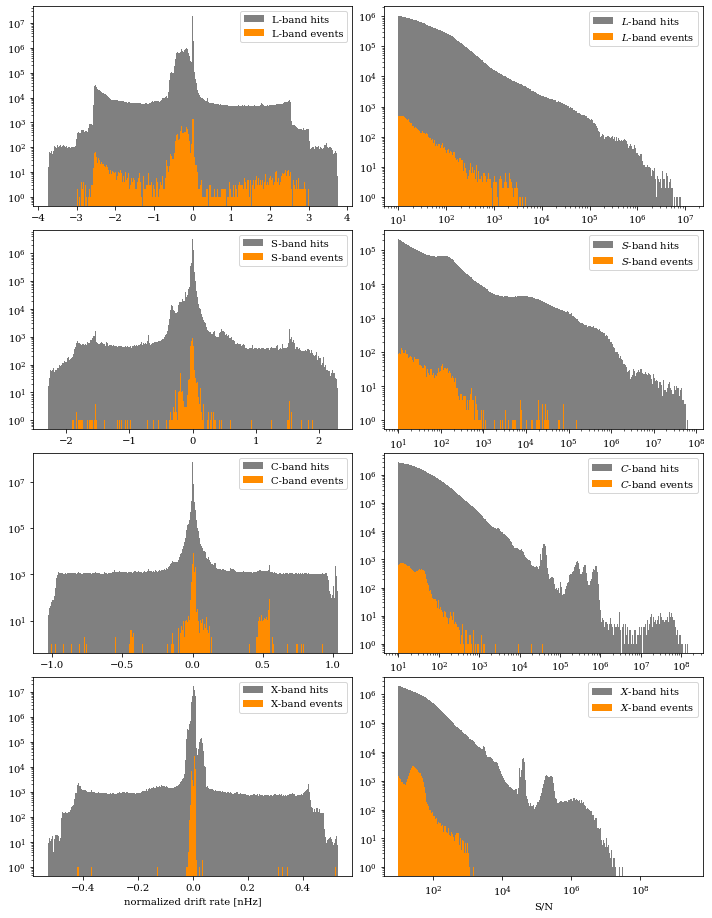

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(12,16))
hit_color = 'gray'
event_color = 'darkorange'
nbins = 300

event_f = dfa['Frequency'].values/1000
event_d = dfa['Drift Rate'].values
event_s = dfa['SNR'].values
event_fvec_L = event_f[np.where(event_f < 1.9)[0]]
event_fvec_S = event_f[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_fvec_C = event_f[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_fvec_X = event_f[np.where(event_f > 7.8)[0]]
event_dvec_L = event_d[np.where(event_f < 1.9)[0]]
event_dvec_S = event_d[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_dvec_C = event_d[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_dvec_X = event_d[np.where(event_f > 7.8)[0]]
event_svec_L = event_s[np.where(event_f < 1.9)[0]]
event_svec_S = event_s[np.where((event_f > 1.9) & (event_f < 2.7))[0]]
event_svec_C = event_s[np.where((event_f > 4) & (event_f < 7.8))[0]]
event_svec_X = event_s[np.where(event_f > 7.8)[0]]

ax[0,0].hist(ldvec/(lfvec/1000), color=hit_color, bins=nbins, label='L-band hits')
ax[1,0].hist(sdvec/(sfvec/1000), color=hit_color, bins=nbins, label='S-band hits')
ax[2,0].hist(cdvec/(cfvec/1000), color=hit_color, bins=nbins, label='C-band hits')
ax[3,0].hist(xdvec/(xfvec/1000), color=hit_color, bins=nbins, label='X-band hits')
ax[0,0].hist(event_dvec_L/(event_fvec_L), color=event_color, bins=nbins, range=(np.min(ldvec/(lfvec/1000)), np.max(ldvec/(lfvec/1000))),
             label=r'$L$-band events')
ax[1,0].hist(event_dvec_S/(event_fvec_S), color=event_color, bins=nbins, range=(np.min(sdvec/(sfvec/1000)), np.max(sdvec/(sfvec/1000))),
             label=r'$S$-band events')
ax[2,0].hist(event_dvec_C/(event_fvec_C), color=event_color, bins=nbins, range=(np.min(cdvec/(cfvec/1000)), np.max(cdvec/(cfvec/1000))),
             label=r'$C$-band events')
ax[3,0].hist(event_dvec_X/(event_fvec_X), color=event_color, bins=nbins, range=(np.min(xdvec/(xfvec/1000)), np.max(xdvec/(xfvec/1000))),
             label=r'$X$-band events')

hist, bins = np.histogram(lsvec, bins=nbins, range=(np.min(lsvec), np.max(lsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[0,1].hist(lsvec, color=hit_color, bins=logbins, label=r'$L$-band hits')
hist, bins = np.histogram(event_svec_L, bins=nbins, range=(np.min(lsvec), np.max(lsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[0,1].hist(event_svec_L, color=event_color, bins=logbins, label=r'$L$-band events')
ax[0,1].set_xscale('log')

hist, bins = np.histogram(ssvec, bins=nbins, range=(np.min(ssvec), np.max(ssvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(ssvec, color=hit_color, bins=logbins, label=r'$S$-band hits')
hist, bins = np.histogram(event_svec_S, bins=nbins, range=(np.min(ssvec), np.max(ssvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(event_svec_S, color=event_color, bins=logbins, label=r'$S$-band events')
ax[1,1].set_xscale('log')

hist, bins = np.histogram(csvec, bins=nbins, range=(np.min(csvec), np.max(csvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[2,1].hist(csvec, color=hit_color, bins=logbins, label=r'$C$-band hits')
hist, bins = np.histogram(event_svec_C, bins=nbins, range=(np.min(csvec), np.max(csvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[2,1].hist(event_svec_C, color=event_color, bins=logbins, label=r'$C$-band events')
ax[2,1].set_xscale('log')

hist, bins = np.histogram(xsvec, bins=nbins, range=(np.min(xsvec), np.max(xsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[3,1].hist(xsvec, color=hit_color, bins=logbins, label=r'$X$-band hits')
hist, bins = np.histogram(event_svec_X, bins=nbins, range=(np.min(xsvec), np.max(xsvec)))
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[3,1].hist(event_svec_X, color=event_color, bins=logbins, label=r'$X$-band events')
ax[3,1].set_xscale('log')


for a in ax.flat:
    a.set_yscale('log')
    a.legend()
ax[3,0].set_xlabel('normalized drift rate [nHz]')
ax[3,1].set_xlabel('S/N')
plt.subplots_adjust(wspace=0.1, hspace=0.12)

plt.savefig('/datax/scratch/benjb/bl_nearby_stars/seticore_output/plots/turboSETI_drift_and_SNR_histograms.pdf', bbox_inches='tight')
plt.show()